In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')

In [2]:
# Load mushroom dataset
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/mushroom/agaricus-lepiota.data'

# Column names
column_names = ['class', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor',
                'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color',
                'stalk-shape', 'stalk-root', 'stalk-surface-above-ring',
                'stalk-surface-below-ring', 'stalk-color-above-ring',
                'stalk-color-below-ring', 'veil-type', 'veil-color',
                'ring-number', 'ring-type', 'spore-print-color',
                'population', 'habitat']

mushroom_data = pd.read_csv(url, names=column_names)
print(f"Dataset shape: {mushroom_data.shape}")
mushroom_data.head(130)

Dataset shape: (8124, 23)


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,stalk-root,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,e,e,s,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,e,c,s,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,e,c,s,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,e,e,s,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,t,e,s,s,w,w,p,w,o,e,n,a,g
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125,e,x,s,w,f,n,f,w,b,n,t,e,s,f,w,w,p,w,o,e,k,s,g
126,e,b,s,y,t,a,f,c,b,w,e,c,s,s,w,w,p,w,o,p,n,n,g
127,e,f,f,g,f,n,f,w,b,h,t,e,s,s,w,w,p,w,o,e,n,a,g
128,e,x,s,w,t,l,f,c,b,n,e,c,s,s,w,w,p,w,o,p,k,n,g


In [3]:
# EDA
print("Dataset Info:")
print(mushroom_data.info())
print(f"\nNumber of features: {mushroom_data.shape[1] - 1}")
print(f"Number of samples: {mushroom_data.shape[0]}")

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   class                     8124 non-null   str  
 1   cap-shape                 8124 non-null   str  
 2   cap-surface               8124 non-null   str  
 3   cap-color                 8124 non-null   str  
 4   bruises                   8124 non-null   str  
 5   odor                      8124 non-null   str  
 6   gill-attachment           8124 non-null   str  
 7   gill-spacing              8124 non-null   str  
 8   gill-size                 8124 non-null   str  
 9   gill-color                8124 non-null   str  
 10  stalk-shape               8124 non-null   str  
 11  stalk-root                8124 non-null   str  
 12  stalk-surface-above-ring  8124 non-null   str  
 13  stalk-surface-below-ring  8124 non-null   str  
 14  stalk-color-above-ring    8124 non-nu

In [4]:
# Check for missing values (represented as '?')
print("Missing values per column:")
missing_counts = (mushroom_data == '?').sum()
print(missing_counts[missing_counts > 0])


Missing values per column:
stalk-root    2480
dtype: int64


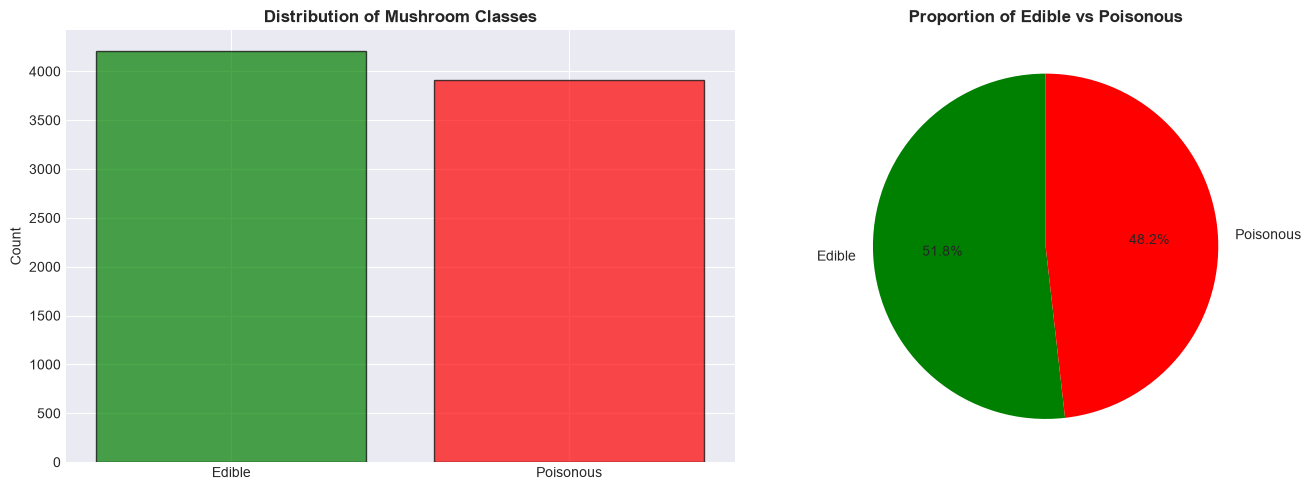

In [5]:
# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

class_counts = mushroom_data['class'].value_counts()
axes[0].bar(['Edible', 'Poisonous'], class_counts.values, 
           color=['green', 'red'], edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of Mushroom Classes', fontweight='bold')
axes[0].set_ylabel('Count')

axes[1].pie(class_counts.values, labels=['Edible', 'Poisonous'], 
           autopct='%1.1f%%', colors=['green', 'red'], startangle=90)
axes[1].set_title('Proportion of Edible vs Poisonous', fontweight='bold')

plt.tight_layout()

In [11]:
# Replace '?' with NaN
mushroom_clean = mushroom_data.replace('?', np.nan)

for col in mushroom_clean.columns:
    # if column has null values will return true
    if mushroom_clean[col].isnull().any():
        mode_val=mushroom_clean[col].mode()[0]
        mushroom_clean[col].fillna(mode_val,inplace=True)
        print(f"Filled {col} with mode: {mode_val}")

mushroom_data = mushroom_clean.copy()

Filled stalk-root with mode: b


In [12]:
#label enconding
from sklearn.preprocessing import LabelEncoder
mushroom_label_encoded = mushroom_data.copy()
label_encoders = {}
for col in mushroom_label_encoded:
    le=LabelEncoder()
    mushroom_label_encoded[col]=le.fit_transform(mushroom_label_encoded[col])
    label_encoders[col]=le

print("Label Encoded Dataset:")
mushroom_label_encoded.head()

Label Encoded Dataset:


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,stalk-root,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,1,5,2,4,1,6,1,0,1,4,0,2,2,2,7,7,0,2,1,4,2,3,5
1,0,5,2,9,1,0,1,0,0,4,0,1,2,2,7,7,0,2,1,4,3,2,1
2,0,0,2,8,1,3,1,0,0,5,0,1,2,2,7,7,0,2,1,4,3,2,3
3,1,5,3,8,1,6,1,0,1,5,0,2,2,2,7,7,0,2,1,4,2,3,5
4,0,5,2,3,0,5,1,1,0,4,1,2,2,2,7,7,0,2,1,0,3,0,1


In [13]:
display(label_encoders)

{'class': LabelEncoder(),
 'cap-shape': LabelEncoder(),
 'cap-surface': LabelEncoder(),
 'cap-color': LabelEncoder(),
 'bruises': LabelEncoder(),
 'odor': LabelEncoder(),
 'gill-attachment': LabelEncoder(),
 'gill-spacing': LabelEncoder(),
 'gill-size': LabelEncoder(),
 'gill-color': LabelEncoder(),
 'stalk-shape': LabelEncoder(),
 'stalk-root': LabelEncoder(),
 'stalk-surface-above-ring': LabelEncoder(),
 'stalk-surface-below-ring': LabelEncoder(),
 'stalk-color-above-ring': LabelEncoder(),
 'stalk-color-below-ring': LabelEncoder(),
 'veil-type': LabelEncoder(),
 'veil-color': LabelEncoder(),
 'ring-number': LabelEncoder(),
 'ring-type': LabelEncoder(),
 'spore-print-color': LabelEncoder(),
 'population': LabelEncoder(),
 'habitat': LabelEncoder()}

In [ ]:
X=mushroom_data.drop(columns=['class'])
y = mushroom_data['class']

#pd.get_dummies() converts categorical text values into numerical 0/1 column
#prefix controls the names of the new columns.
#prefix=X.columns ->  means: Use each original column name as the prefix for its encoded columns.
#drop_first=False -> Keep all categories. Don't remove the first category
x_onehot=pd.get_dummies(X,prefix=X.columns,drop_first=False)
print(f"Original features: {X.shape[1]}")
print(f"After one-hot encoding: {x_onehot.shape[1]}")

Original features: 22
After one-hot encoding: 116


In [16]:
display(x_onehot.columns)

Index(['cap-shape_b', 'cap-shape_c', 'cap-shape_f', 'cap-shape_k',
       'cap-shape_s', 'cap-shape_x', 'cap-surface_f', 'cap-surface_g',
       'cap-surface_s', 'cap-surface_y',
       ...
       'population_s', 'population_v', 'population_y', 'habitat_d',
       'habitat_g', 'habitat_l', 'habitat_m', 'habitat_p', 'habitat_u',
       'habitat_w'],
      dtype='str', length=116)

In [17]:
# Featured Engineering
mushroom_featured = mushroom_label_encoded.copy()

# Color diversity
color_features = ['cap-color', 'gill-color', 'stalk-color-above-ring', 
                 'stalk-color-below-ring', 'veil-color', 'spore-print-color']
mushroom_featured['color_diversity'] = mushroom_label_encoded[color_features].nunique(axis=1)

# Surface consistency
mushroom_featured['surface_consistent'] = (
    mushroom_label_encoded['stalk-surface-above-ring'] == 
    mushroom_label_encoded['stalk-surface-below-ring']
).astype(int)

print("New features created:")
print(mushroom_featured[['color_diversity', 'surface_consistent']].head())


New features created:
   color_diversity  surface_consistent
0                3                   1
1                5                   1
2                5                   1
3                4                   1
4                4                   1


In [18]:
mushroom_label_encoded.to_csv('mushroom_label_encoded.csv', index=False)
x_onehot.to_csv('mushroom_onehot_features.csv', index=False)
print("Processed datasets saved!")

Processed datasets saved!
